# Reverse Diffusion: Training-Free Score Estimation

- 신경망 없이 score $s(x,t) = \nabla_x \log p_t(x)$를 추정하는 방법 구현  
- Euler-Maruyama와 Probability Flow ODE(RK4)로 reverse diffusion을 비교

| Case | Score 추정 방법 |
|------|----------------|
| 0 | GMM 해석적 score (기준선) |
| 1 | Fokker-Planck PDE 수치적분 → $p_t$ |
---

### 초기 세팅
$$\bar{\alpha}(t) = \exp \left(\int_0^t \log(1-\beta(s))ds\right)$$

β가 작을 때 $\log(1-\beta) \approx -\beta$ 이므로:

$$\bar{\alpha}(t) \approx \exp \left(-\int_0^t \beta(s)ds\right)$$
linear schedule이므로 $\beta(s) = a + b \cdot s$ 여기서:

$a$ = _beta_start = 1e-4
$b$ = (_beta_end - _beta_start) / (T-1)
이걸 적분하면:

$$\int_0^t \beta(s),ds = \int_0^t (a + b\cdot s),ds = a\cdot t + \frac{b}{2}\cdot t^2$$

최종
$$\boxed{\bar{\alpha}(t) = \exp \left(-(a\cdot t + \tfrac{b}{2}\cdot t^2)\right)}$$

In [47]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


# ── dataset setting ───────────────────────────────────────────────────────────
def make_samples(means, std, n_per_mode):
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])


# Grid
g = np.linspace(-2, 2, 3)
grid_means = np.array([[x, y] for y in g for x in g])

# Moons
th = np.linspace(0, np.pi, 300)
moon_means = np.vstack(
    [
        np.column_stack([np.cos(th), np.sin(th)]),
        np.column_stack([1 - np.cos(th), 1 - np.sin(th) - 0.5]),
    ]
)

# Heart
t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = (
    np.column_stack(
        [
            16 * np.sin(t) ** 3,
            13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t),
        ]
    )
    / 10
)

datasets = {
    "grid": make_samples(grid_means, std=0.12, n_per_mode=150),
    "moons": make_samples(moon_means, std=0.06, n_per_mode=1),
    "heart": make_samples(heart_means, std=0.07, n_per_mode=80),
}

# ── Noise schedule (연속 함수) ─────────────────────────────────────────────────
T = 500
_beta_start = 1e-4
_beta_end   = 0.02

def beta_fn(t):
    """t ∈ [0, T-1] 연속값 → beta (linear schedule)"""
    t = np.clip(t, 0, T - 1)
    return _beta_start + (_beta_end - _beta_start) * t / (T - 1)

def alpha_bar_fn(t):
    """t ∈ [0, T-1] 연속값 → ᾱ(t) = exp(-∫₀ᵗ β(s)ds)"""
    t = np.clip(t, 0, T - 1)
    a = _beta_start
    b = (_beta_end - _beta_start) / (T - 1)
    return np.exp(-(a * t + 0.5 * b * t**2))

def sigma2_fn(t):
    """t ∈ [0, T-1] 연속값 → σ²(t) = 1 - ᾱ(t)"""
    return 1.0 - alpha_bar_fn(t)

SAVE_STEPS = [0, 100, 200, 300, 400, 500]

In [48]:
def plot_steps(traj, steps=None, order="asc", color="#3498db", title=""):
    """스텝별 분포 시각화.

    order: "asc"  → t 오름차순 (forward, 0→T)
           "desc" → t 내림차순 (reverse, T→0)
    """
    if steps is None:
        steps = sorted(traj.keys())

    if order == "asc":
        steps = list(steps)
    elif order == "desc":
        steps = list(reversed(steps))
    else:
        raise ValueError(f"order must be 'asc' or 'desc', got {order!r}")

    ncols = int(len(steps) / 2)
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    for ax, t in zip(axes.flatten(), steps):
        pts = traj.get(t)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## Forward VP-SDE

$$dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW$$

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s$$
---

In [49]:
# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved

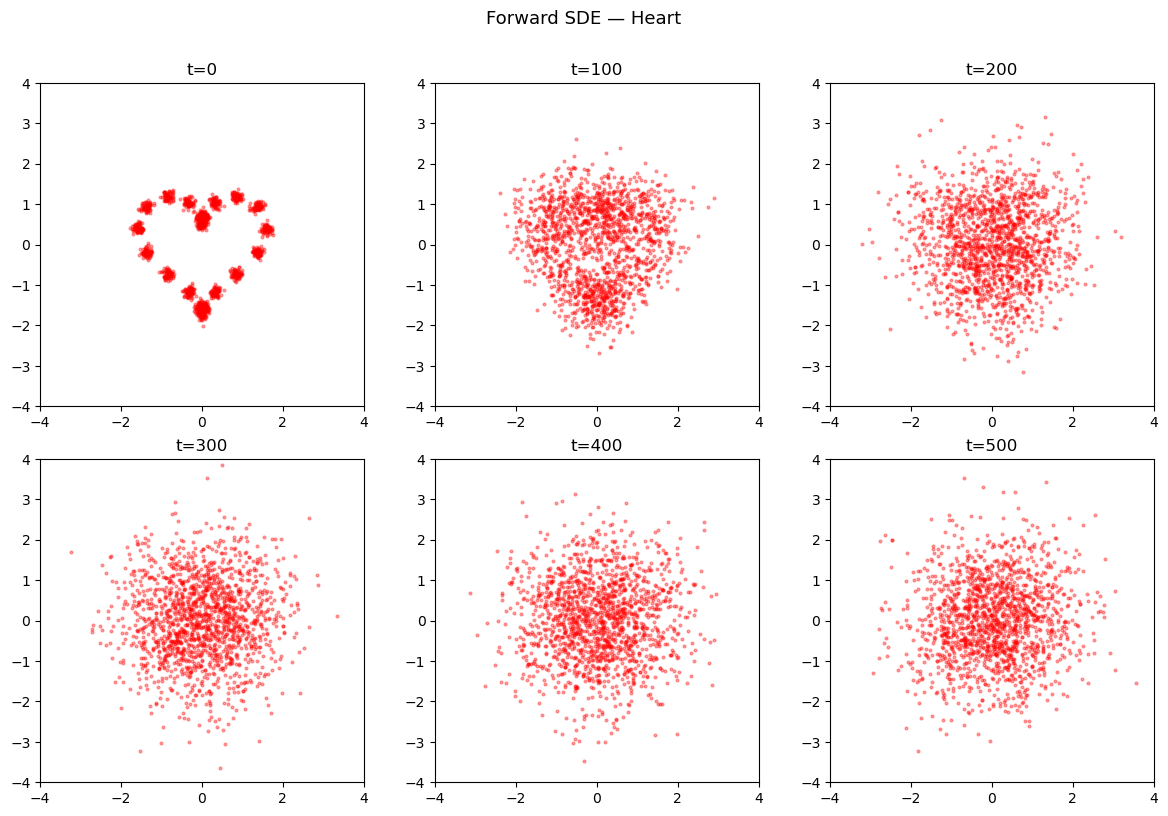

In [50]:
# ── Heart forward 확인 ────────────────────────────────────────────────────────
fwd = {}
for name, x0 in datasets.items():
    fwd[name] = forward_sde(x0)

plot_steps(fwd["heart"], steps=SAVE_STEPS, order="asc", color="red", title="Forward SDE — Heart")

## Forward VP-SDE 수식 증명

### Forward VP-SDE
$$
dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW
$$

$$
x_t-x_{t-1}=-\frac{1}{2}\beta_t x_{t-1}+\sqrt{\beta_t}\epsilon
$$

$$
x_t=\left(1-\frac{1}{2}\beta_t \right) x_{t-1}+\sqrt{\beta_t}\epsilon
$$
<br>
    
$1-\frac{1}{2}\beta_t \equiv \sqrt{1-\beta_t}$ ($\beta_t$가 작을 때) 이므로:  
$$
x_t=\sqrt{1-\beta_t}x_{t-1}+\sqrt{\beta_t}\epsilon
= \sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon
$$
$$\alpha_t = 1 - \beta_t$$



### 한 스텝 점화식
 
$$\mathbf{x}_t = \sqrt{\alpha_t}\,\mathbf{x}_{t-1} + \sqrt{1-\alpha_t}\,\boldsymbol{\epsilon}_t, \qquad \boldsymbol{\epsilon}_t \sim \mathcal{N}(0,I)$$
 
### 반복 대입
 
**$t=1$:**
 
$$\mathbf{x}_1 = \sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1$$
 
**$t=2$:** $\mathbf{x}_1$을 대입:
 
$$\mathbf{x}_2 = \sqrt{\alpha_2}\,\mathbf{x}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_2}\left(\sqrt{\alpha_1}\,\mathbf{x}_0 + \sqrt{1-\alpha_1}\,\boldsymbol{\epsilon}_1\right) + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2$$
 
$$= \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \underbrace{\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2}_{\text{두 독립 가우시안의 합}}$$
 
### 노이즈 항 합치기
 
두 독립 가우시안의 합의 분산:
 
$$\text{Var} = \alpha_2(1-\alpha_1) + (1-\alpha_2) = \alpha_2 - \alpha_1\alpha_2 + 1 - \alpha_2 = 1 - \alpha_1\alpha_2$$
 
따라서 두 노이즈를 하나의 가우시안으로 합칠 수 있다:
 
$$\sqrt{\alpha_2(1-\alpha_1)}\,\boldsymbol{\epsilon}_1 + \sqrt{1-\alpha_2}\,\boldsymbol{\epsilon}_2 = \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon}\sim\mathcal{N}(0,I)$$
 
따라서:
 
$$\mathbf{x}_2 = \sqrt{\alpha_1\alpha_2}\,\mathbf{x}_0 + \sqrt{1-\alpha_1\alpha_2}\,\boldsymbol{\epsilon}$$

### 일반화
 
같은 과정을 $t$번 반복하면 노이즈 항의 분산이:
 
$$1-\alpha_1\alpha_2, \quad 1-\alpha_1\alpha_2\alpha_3, \quad \ldots, \quad 1-\prod_{s=1}^t\alpha_s = 1-\bar{\alpha}_t$$
 
따라서:
 
$$\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s}$$

## Reverse SDE (Anderson, 1982)

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

---

## Euler-Maruyama (SDE Solver)
$$x_{t-1} = x_t + \beta_t\!\left(-\tfrac{1}{2}x_t - s(x_t,t)\right)\Delta t + \sqrt{\beta_t\Delta t}\,\epsilon$$
---

In [51]:
def reverse_euler(x_T, t_arr, score_fn):
    traj = {t_arr[0]: x_T.copy()}
    x = x_T.copy()
    dt = -1
    for t in t_arr[1:]:
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
        traj[t] = x.copy()
    return traj

## Probability Flow ODE (RK4: ODE Solver)
### 핵심 목표
 
**노이즈를 없애되, $p_t$의 시간 변화는 동일하게 유지**
 
SDE와 ODE는 서로 다른 방정식이지만, **Fokker-Planck 수준에서 일치하면 같은 $p_t$를 만들어냄.**

$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 
---

In [52]:
# RK4
def ODE_MV_RK4(f, r, t, **kwargs):
    h = t[1] - t[0]
    k = np.zeros((4, *r.shape[1:]), float)
    for i in range(len(t) - 1):
        k[0] = h * f(r[i], t[i], **kwargs)
        k[1] = h * f(r[i] + k[0] / 2, t[i] + h / 2, **kwargs)
        k[2] = h * f(r[i] + k[1] / 2, t[i] + h / 2, **kwargs)
        k[3] = h * f(r[i] + k[2], t[i] + h, **kwargs)
        r[i + 1] = r[i] + (k[0] + 2 * k[1] + 2 * k[2] + k[3]) / 6
    return r


# Probability Flow ODE — 연속 t 사용
def PF_ODE(x, t, score_fn):
    b = beta_fn(t)
    s = score_fn(x, t)
    return -0.5 * b * x - 0.5 * b * s


def reverse_rk4(x_T, t_arr, score_fn):
    """Probability Flow ODE (deterministic), RK4 적분"""
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = ODE_MV_RK4(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj

## Probability Flow ODE 증명

### Step 1: Reverse SDE의 Fokker-Planck 방정식
 
Reverse SDE:
 
$$dx = \underbrace{\left[-\frac{1}{2}\beta x - \beta s\right]}_{f}\,dt + \underbrace{\sqrt{\beta}}_{g}\,d\bar{W}$$
 
이 SDE의 Fokker-Planck 방정식:
 
$$\frac{\partial p}{\partial t} = \underbrace{-\nabla\cdot(f\cdot p)}_{\text{drift 기여}} + \underbrace{\frac{1}{2}g^2\,\nabla^2 p}_{\text{노이즈 기여}}$$
 
---
 
### Step 2: ODE의 Fokker-Planck 방정식
 
ODE $\dfrac{dx}{dt} = \tilde{f}$의 Fokker-Planck:
 
$$\frac{\partial p}{\partial t} = -\nabla\cdot(\tilde{f}\cdot p)$$
 
노이즈가 없으니 두 번째 항이 없음.
 
---
 
### Step 3: 두 Fokker-Planck를 같게 놓기
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \frac{1}{2}g^2\,\nabla^2 p$$
 
우변의 노이즈 항 $\dfrac{1}{2}g^2\,\nabla^2 p$을 $-\nabla\cdot(\cdot\, p)$ 꼴로 변환.
 
$$\frac{1}{2}g^2\,\nabla^2 p = \frac{1}{2}g^2\,\nabla\cdot(\nabla p)$$
 
여기서 $\nabla p = p \cdot \nabla\log p = p \cdot s$ 이므로:
 
$$= \nabla\cdot\!\left(\frac{1}{2}g^2\, s\cdot p\right)$$
 
따라서:
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \nabla\cdot\!\left(\frac{1}{2}g^2\,s\cdot p\right) = -\nabla\cdot\!\left[\left(f - \frac{1}{2}g^2\,s\right)p\right]$$
 
$$\boxed{\tilde{f} = f - \frac{1}{2}g^2\,s}$$
 
---
 
### Step 4: 대입
 
$f = -\dfrac{1}{2}\beta x - \beta s$, $\quad g^2 = \beta$ 를 대입:
 
$$\tilde{f} = \left(-\frac{1}{2}\beta x - \beta s\right) - \frac{1}{2}\beta s = -\frac{1}{2}\beta x - \frac{1}{2}\beta s$$
 
최종 Probability Flow ODE:
 
$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 

---
## Case 0 — GMM Exact Score + Euler vs RK4

VP-SDE의 marginal(주변분포, $x_t$)은 GMM(Gaussian Mixture Model)을 유지:
$$p_t(x) = \frac{1}{K}\sum_k \mathcal{N}\!\left(x;\;\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2 + \sigma_t^2\right)$$

Score는 각 모드 score의 **사후확률 가중 합**:
$$s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right), \qquad w_k = \frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}$$

이것이 신경망 없이 구할 수 있는 **이론상 완벽한 score**

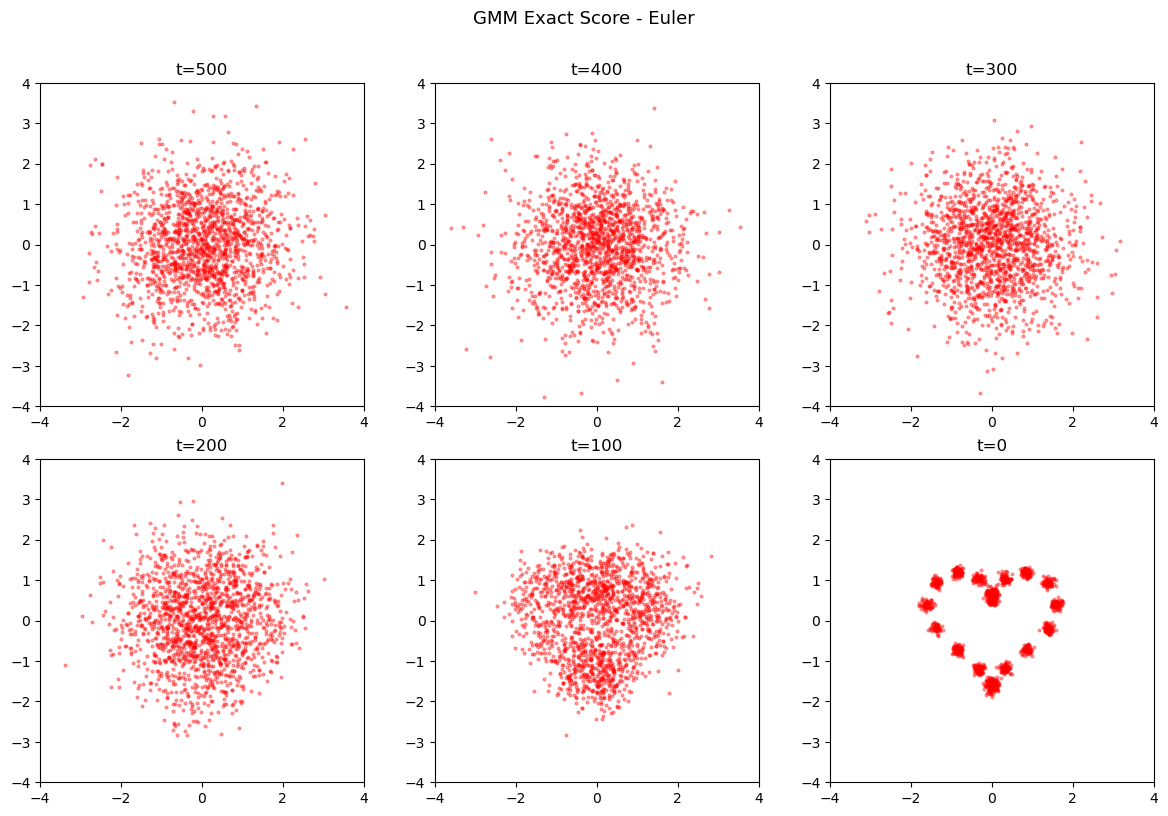

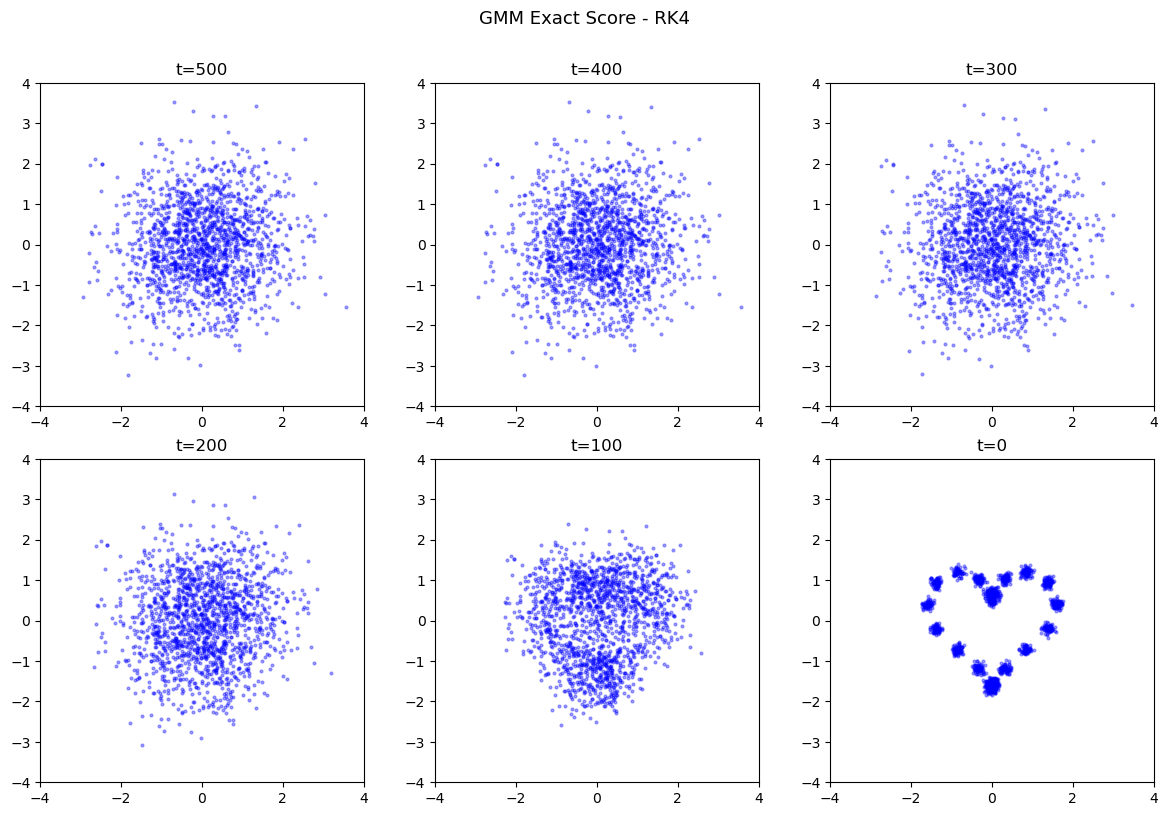

In [53]:
from functools import partial

def gmm_score(x, t, means, var):
    ab = alpha_bar_fn(t)
    s2 = sigma2_fn(t)
    mu_t = np.sqrt(ab) * means   # K개 2D Gaussian 중심점 배열: (K,2)
    var_t = ab * var + s2        # scalar: (K,2)

    # N개의 각 점에서 K개의 중심점까지의 차이벡터
    # x: (N,2) -> (N,1,2)
    # mu_t: (K,2) -> (1,K,2)
    # diff: (N,1,2) - (1,K,2) = (N,K,2) - broadcasting
    diff = x[:, None, :] - mu_t[None, :, :]

    # Gaussain 밀도 구하는 과정
    # .sum(-1)으로 마지막 축(좌표 2개)을 합산: (dx)^2 + (dy)^2 = ‖x−μ‖²
    # (N,K,2) -> (N,K)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    # 최댓값 빼며 exp overflow 방지 - softmax 과정에서 상쇄
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    # softmax
    wk /= wk.sum(1, keepdims=True)  # (N,K) — 사후확률 w_k(x,t)

    score_k = -diff / var_t      # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


t_arr = np.arange(T, -1, -1)
heart_score = partial(gmm_score, means=heart_means, var=0.07**2)

x_T = fwd["heart"][T].copy()
traj_e0 = reverse_euler(x_T, t_arr, heart_score)
traj_r0 = reverse_rk4(x_T, t_arr, heart_score)

plot_steps(traj_e0, steps=SAVE_STEPS, order="desc", color="red", title="GMM Exact Score - Euler")
plot_steps(traj_r0, steps=SAVE_STEPS, order="desc", color="blue", title="GMM Exact Score - RK4")

## GMM Exact Score 증명
---

주어진 데이터 $x_0$가 GMM(Gaussian Mixture Model)이라 가정:
$$
p_0(x_0)=\frac{1}{K} \sum_{k=1}^{K} \mathcal{N}(x_0;\mu_k,\sigma_k^2 I)
$$

---

### 1. GMM marginal $p_t(x)$ 유도

> $x_0 \sim \mathcal{N}(\mu_k,\,\sigma_k^2)$ 에서 샘플하고,  
> forward process 적용: $x_t = \sqrt{\bar\alpha_t}\,x_0 + \epsilon,\quad \epsilon \sim \mathcal{N}(0,\sigma_t^2)$  
> $\Rightarrow$ $x_t$의 분포는?

$x_t$는 **가우시안의 선형 변환 + 독립 가우시안** 이므로 평균과 분산만 추적하면 됨:

$$\mathbb{E}[x_t] = \sqrt{\bar\alpha_t}\,\mathbb{E}[x_0] + 0 = \sqrt{\bar\alpha_t}\,\mu_k$$

$$\text{Var}[x_t] = (\sqrt{\bar\alpha_t})^2\,\text{Var}[x_0] + \text{Var}[\epsilon] = \bar\alpha_t\sigma_k^2 + \sigma_t^2$$

가우시안의 선형 변환은 가우시안이므로:
$$x_t \sim \mathcal{N}(x;\,\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2+\sigma_t^2)$$

### 최종 결과

$$\boxed{p_t(x) = \frac{1}{K}\sum_k \mathcal{N}(x;\sqrt{\bar\alpha_t}\mu_k,\,\bar\alpha_t\sigma_k^2+\sigma_t^2)}$$

---

### 2. Score $\nabla_x \log p_t(x)$ 유도

$p_t$를 알고 있으니 log를 취하고 미분하면 되는데, 합의 log는 바로 미분이 안 됨.

$\log$를 먼저 분리:

$$\log p_t(x) = \log \sum_k \underbrace{\frac{1}{K}\mathcal{N}(x;\sqrt{\bar\alpha_t}\mu_k,\,\bar\alpha_t\sigma_k^2+\sigma_t^2)}_{=p_t^{(k)}(x)}$$

$\nabla_x$를 취하면 (log-sum 미분):

$$\nabla_x \log p_t(x) = \frac{\nabla_x \sum_k p_t^{(k)}(x)}{\sum_k p_t^{(k)}(x)} = \sum_k \underbrace{\frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}}_{=w_k(x,t)} \cdot \nabla_x \log p_t^{(k)}(x)$$

$$
w_k = \frac{k\text{번째 Gaussian이 현재 }x\text{에 부여하는 밀도}}{\text{모든 Gaussian이 현재 }x\text{에 부여하는 밀도의 총합}}
$$

각 가우시안의 score ($\mu_k^t = \sqrt{\bar\alpha_t}\mu_k$, $v_k^t = \bar\alpha_t\sigma_k^2 + \sigma_t^2$):

$$\nabla_x \log \mathcal{N}(x;\mu_k^t, v_k^t) = -\frac{x - \mu_k^t}{v_k^t}$$

최종:

$$\boxed{s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar{\alpha_t}\sigma_k^2+\sigma_t^2}\right)}$$


## debugging

In [54]:

# ── 디버깅 1: 스텝별 x 통계 ──────────────────────────────────────────────────
debug_steps = [500, 400, 300, 200, 100, 50, 10, 1, 0]

print(f"{'t':>5} | {'N':>5} | {'mean_x':>8} | {'std_x':>8} | {'score_mag':>10} | {'drift_mag':>10}")
print("-" * 65)
for t in debug_steps:
    pts = traj_e0[t]
    b = beta_fn(t)
    s = heart_score(pts, t)
    drift = b * (-0.5 * pts - s)
    print(f"{t:>5} | {len(pts):>5} | {pts.mean():>8.4f} | {pts.std():>8.4f} | "
          f"{np.linalg.norm(s, axis=1).mean():>10.4f} | {np.linalg.norm(drift, axis=1).mean():>10.4f}")


    t |     N |   mean_x |    std_x |  score_mag |  drift_mag
-----------------------------------------------------------------
  500 |  1600 |   0.0223 |   1.0204 |     1.2787 |     0.0128
  400 |  1600 |  -0.0018 |   0.9950 |     1.2427 |     0.0100
  300 |  1600 |   0.0104 |   0.9958 |     1.2652 |     0.0077
  200 |  1600 |   0.0015 |   1.0006 |     1.2843 |     0.0053
  100 |  1600 |   0.0180 |   0.9680 |     1.7275 |     0.0058
   50 |  1600 |   0.0259 |   0.9541 |     3.5016 |     0.0070
   10 |  1600 |   0.0232 |   0.9512 |    12.8426 |     0.0064
    1 |  1600 |   0.0230 |   0.9517 |    16.4473 |     0.0023
    0 |  1600 |   0.0229 |   0.9518 |    16.5893 |     0.0017


In [55]:

# ── 디버깅 2: t=1 근처에서 score vs noise 크기 비교 ──────────────────────────
print("t  | var_t    | score_mag | noise_std | drift_mag")
print("-" * 55)
for t in [10, 5, 2, 1, 0]:
    ab = alpha_bar_fn(t)
    s2 = sigma2_fn(t)
    var_t = ab * 0.07**2 + s2
    b = beta_fn(t)

    pts = traj_e0[t]
    s = heart_score(pts, t)
    drift = b * (-0.5 * pts - s)

    print(f"{t:>2} | {var_t:.6f} | {np.linalg.norm(s, axis=1).mean():>9.4f} | "
          f"{np.sqrt(b):>9.4f} | {np.linalg.norm(drift, axis=1).mean():>9.4f}")


t  | var_t    | score_mag | noise_std | drift_mag
-------------------------------------------------------
10 | 0.007875 |   12.8426 |    0.0223 |    0.0064
 5 | 0.005893 |   14.8619 |    0.0173 |    0.0044
 2 | 0.005178 |   16.1425 |    0.0134 |    0.0029
 1 | 0.005019 |   16.4473 |    0.0118 |    0.0023
 0 | 0.004900 |   16.5893 |    0.0100 |    0.0017


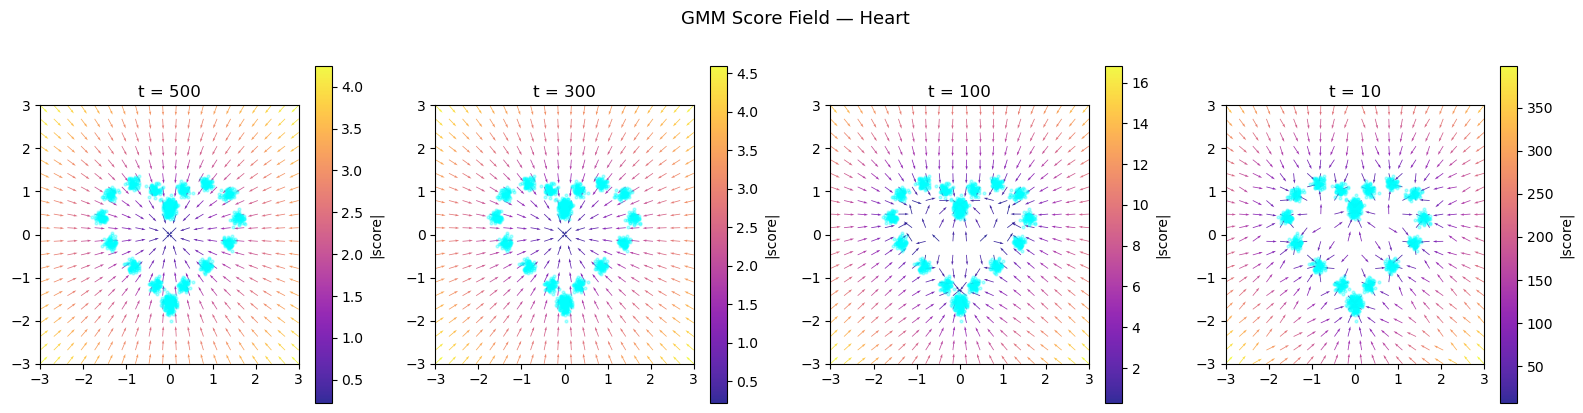

In [56]:

def plot_score_field(score_fn, t_list, n=20, data_pts=None, title="Score Field"):
    """격자 위에서 score 벡터 필드를 quiver로 시각화."""
    fig, axes = plt.subplots(1, len(t_list), figsize=(4 * len(t_list), 4))
    if len(t_list) == 1:
        axes = [axes]

    gx = np.linspace(-3, 3, n)
    gy = np.linspace(-3, 3, n)
    XX, YY = np.meshgrid(gx, gy)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)

    for ax, t in zip(axes, t_list):
        s = score_fn(grid, t)          # (n*n, 2)
        mag = np.linalg.norm(s, axis=1, keepdims=True)
        s_norm = s / (mag + 1e-8)      # 방향만 (크기는 색으로 표현)

        q = ax.quiver(
            XX, YY,
            s_norm[:, 0].reshape(n, n),
            s_norm[:, 1].reshape(n, n),
            mag.reshape(n, n),
            cmap="plasma", scale=25, alpha=0.85,
        )
        plt.colorbar(q, ax=ax, label="|score|")

        if data_pts is not None:
            ax.scatter(*data_pts.T, s=4, alpha=0.3, c="cyan", zorder=3)

        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.set_title(f"t = {t}")

    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# 여러 시간대에서 heart score 시각화
t_vis = [500, 300, 100, 10]
plot_score_field(
    heart_score, t_vis,
    data_pts=datasets["heart"],
    title="GMM Score Field — Heart"
)
